# ASTRA-LM Experiment Analysis
Use this notebook to analyze and compare results from different experiment runs.

In [580]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import glob
from IPython.display import display

## Select Experiment Directory
You can analyze either a baseline comparison run (from `outputs/compare_gpt_vs_vayusphere`) or a VayuSphere v0.2 ablation run (from `outputs/ablate_v2`). The cell below auto-detects the latest run of both types and defaults to the most recent one.

In [581]:
# Detect if running from the 'notebooks' directory or the project root
base_dir = ".." if os.path.basename(os.getcwd()) == "notebooks" else "."

compare_path = os.path.join(base_dir, "outputs", "compare_gpt_vs_vayusphere")
ablate_path = os.path.join(base_dir, "outputs", "ablate_v2")

# Sort runs by modification time so that the most recent run is always last (-1)
compare_runs = sorted(glob.glob(os.path.join(compare_path, "*")), key=os.path.getmtime) if os.path.exists(compare_path) else []
ablate_runs = sorted(glob.glob(os.path.join(ablate_path, "*")), key=os.path.getmtime) if os.path.exists(ablate_path) else []

latest_compare = compare_runs[-1] if compare_runs else None
latest_ablate = ablate_runs[-1] if ablate_runs else None

print("Available runs (sorted by last modified):")
if latest_compare:
    print(f"  [compare] Latest Comparison: {latest_compare}")
if latest_ablate:
    print(f"  [ablate]  Latest Ablation:   {latest_ablate}")

# Default to the most recently modified run directory
run_to_analyze = None
if latest_compare and latest_ablate:
    if os.path.getmtime(latest_compare) > os.path.getmtime(latest_ablate):
        run_to_analyze = latest_compare
    else:
        run_to_analyze = latest_ablate
elif latest_compare:
    run_to_analyze = latest_compare
elif latest_ablate:
    run_to_analyze = latest_ablate

# Alternatively, manual override (uncomment and customize):
# # run_to_analyze = os.path.join(ablate_path, "your_run_here")

if run_to_analyze:
    print(f"\nAnalyzing: {run_to_analyze}")
else:
    print("\nNo experiment runs found.")

Available runs (sorted by last modified):
  [compare] Latest Comparison: ..\outputs\compare_gpt_vs_vayusphere\20260621_212027_seed42_scratch_fair
  [ablate]  Latest Ablation:   ..\outputs\ablate_v2\control_run

Analyzing: ..\outputs\ablate_v2\control_run


## Load Ablation Results Summary
If the selected run is a VayuSphere v0.2 ablation study, it contains a summary CSV (`ablation_results.csv`) of all trained model variants.

In [582]:
if run_to_analyze:
    # 1. Ablation results
    summary_file = os.path.join(run_to_analyze, "ablation_results.csv")
    if os.path.exists(summary_file):
        print("--- Ablation Results Summary Table ---")
        df_summary = pd.read_csv(summary_file)
        display(df_summary)
    else:
        print("Ablation summary table (ablation_results.csv) not found (run may be active). Building live summary from active subdirectories...")
        # Search for metrics.csv files
        subdirs = [d for d in os.listdir(run_to_analyze) if os.path.isdir(os.path.join(run_to_analyze, d))]
        all_metrics = []
        for sd in subdirs:
            if sd.startswith("seed"):
                seed_dir = os.path.join(run_to_analyze, sd)
                inner_dirs = [d for d in os.listdir(seed_dir) if os.path.isdir(os.path.join(seed_dir, d))]
                for idir in inner_dirs:
                    all_metrics.append((f"{sd}/{idir}", os.path.join(seed_dir, idir, "metrics.csv"), idir))
            else:
                all_metrics.append((sd, os.path.join(run_to_analyze, sd, "metrics.csv"), sd))
                
        live_rows = []
        for label, m_file, name in all_metrics:
            if os.path.exists(m_file):
                try:
                    df_m = pd.read_csv(m_file)
                    # Extract last step and loss
                    last_step = df_m['step'].max() if 'step' in df_m.columns else None
                    
                    # Extract eval loss if available, otherwise train loss
                    eval_df = df_m.dropna(subset=['eval_loss'])
                    if not eval_df.empty:
                        last_loss = eval_df.iloc[-1]['eval_loss']
                        last_ppl = eval_df.iloc[-1]['eval_perplexity']
                        loss_type = "eval"
                    else:
                        train_df = df_m.dropna(subset=['loss'])
                        last_loss = train_df.iloc[-1]['loss'] if not train_df.empty else None
                        last_ppl = None
                        loss_type = "train"
                        
                    live_rows.append({
                        "name": label,
                        "last_step": last_step,
                        "latest_loss": last_loss,
                        "loss_type": loss_type,
                        "latest_perplexity": last_ppl
                    })
                except Exception as e:
                    pass
        if live_rows:
            df_summary = pd.DataFrame(live_rows)
            display(df_summary)
        else:
            print("No active metrics.csv files found yet.")

    # 2. Re-evaluation results
    reeval_file = os.path.join(run_to_analyze, "reevaluation_results.csv")
    if os.path.exists(reeval_file):
        print("\n--- Re-evaluation Results Table (Larger Validation Set) ---")
        df_reeval = pd.read_csv(reeval_file)
        display(df_reeval)

    # 3. Multi-seed aggregate results
    agg_file = os.path.join(run_to_analyze, "aggregate_mean_std.csv")
    if os.path.exists(agg_file):
        print("\n--- Aggregated Multi-Seed Results Table ---")
        df_agg = pd.read_csv(agg_file)
        display(df_agg)

--- Ablation Results Summary Table ---


,name,loss,perplexity,params,peak_mem_mb,total_time_sec,tokens_per_sec,max_steps,eval_points,slowdown_vs_baseline
0,A_baseline,6.2830,535.3856,16999430,642.370605,291.437334,17568.099245,10000,10,1.000000
1,B_learned_temp,6.2783,532.8792,16999478,645.385254,300.441918,17041.563400,10000,10,1.030897
2,D_vs_scale_topk8,6.2779,532.6954,17005574,654.212402,466.318683,10979.615840,10000,10,1.600065
3,D_frozen_random_centroids_topk8_prerope,6.2789,533.1822,17005574,652.261230,459.127550,11151.585221,10000,10,1.575390


## Load and Plot Metrics

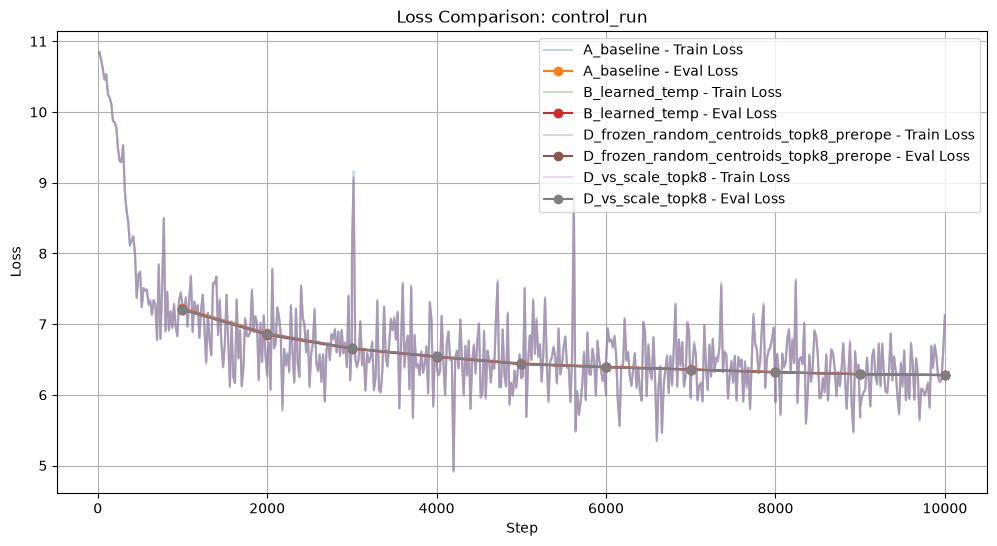

In [583]:
if run_to_analyze:
    subdirs = [d for d in os.listdir(run_to_analyze) if os.path.isdir(os.path.join(run_to_analyze, d))]
    
    plt.figure(figsize=(12, 6))
    
    all_metrics = []
    for sd in subdirs:
        if sd.startswith("seed"):
            seed_dir = os.path.join(run_to_analyze, sd)
            inner_dirs = [d for d in os.listdir(seed_dir) if os.path.isdir(os.path.join(seed_dir, d))]
            for idir in inner_dirs:
                all_metrics.append((f"{sd}/{idir}", os.path.join(seed_dir, idir, "metrics.csv")))
        else:
            all_metrics.append((sd, os.path.join(run_to_analyze, sd, "metrics.csv")))
            
    for label, metrics_file in all_metrics:
        if os.path.exists(metrics_file):
            df = pd.read_csv(metrics_file)
            # Plot loss
            plt.plot(df['step'], df['loss'].interpolate(), label=f"{label} - Train Loss", alpha=0.3)
            
            # Plot eval loss
            eval_df = df.dropna(subset=['eval_loss'])
            if not eval_df.empty:
                plt.plot(eval_df['step'], eval_df['eval_loss'], marker='o', label=f"{label} - Eval Loss")
    
    plt.title(f"Loss Comparison: {os.path.basename(run_to_analyze)}")
    plt.xlabel("Step")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

## VayuSphere Diagnostics
If VayuSphere was active, we can check its gate and gradient statistics.


--- VayuSphere Diagnostics for D_frozen_random_centroids_topk8_prerope ---


,step,vs_q_gate_mean,vs_k_gate_mean,vs_centroid_grad_norm,vs_centroid_usage_entropy,vs_top_centroid_usage_ratio


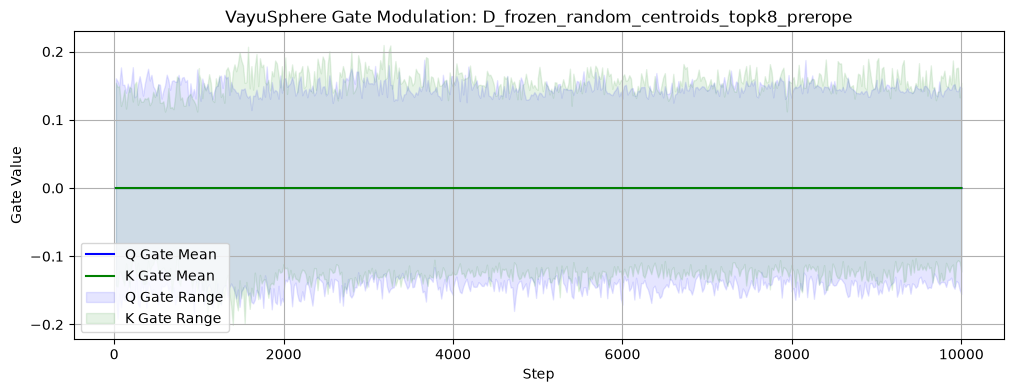

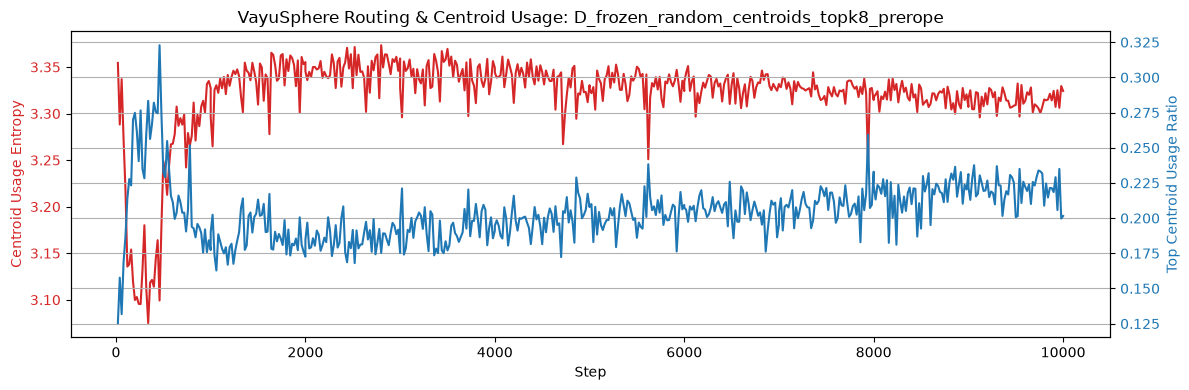


--- VayuSphere Diagnostics for D_vs_scale_topk8 ---


,step,vs_q_gate_mean,vs_k_gate_mean,vs_centroid_grad_norm,vs_centroid_usage_entropy,vs_top_centroid_usage_ratio
504,9920,0.000494,0.000564,0.002773,3.208189,0.189799
505,9940,0.000609,0.000928,0.003931,3.222691,0.184082
506,9960,0.000451,0.000719,0.002928,3.209666,0.187561
507,9980,0.000335,0.000509,0.003190,3.225627,0.176168
508,10000,0.000672,0.000409,0.003287,3.233731,0.175618


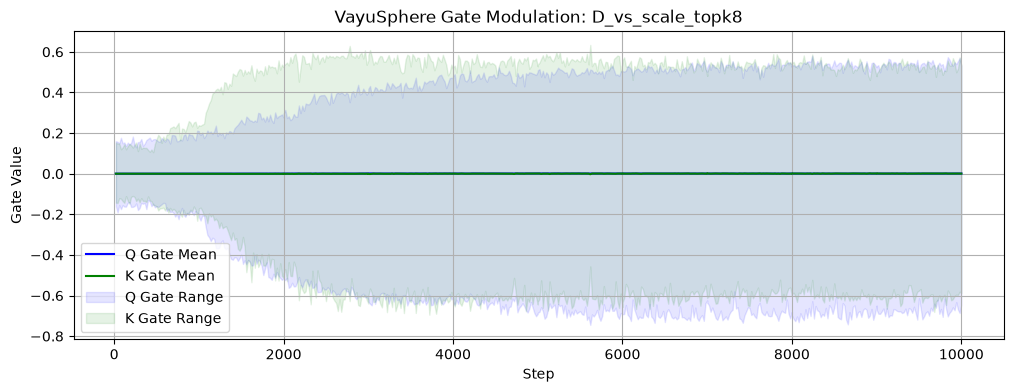

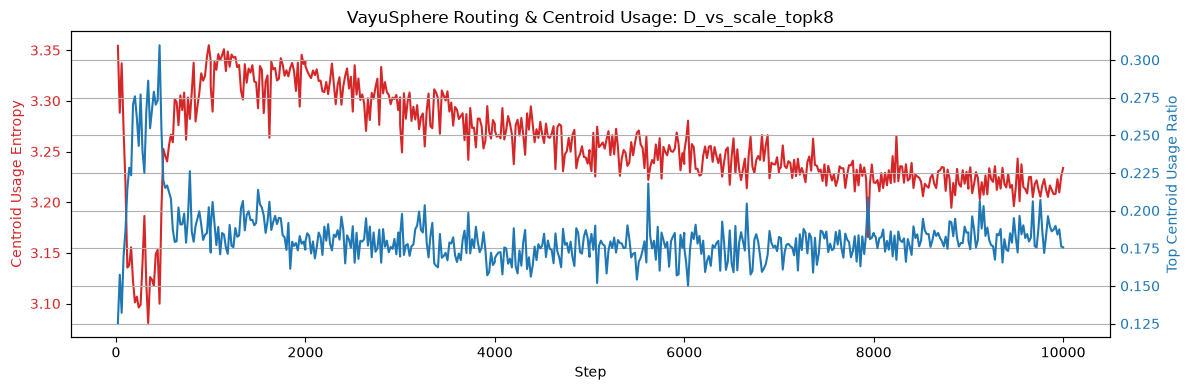

In [584]:
if run_to_analyze:
    subdirs = [d for d in os.listdir(run_to_analyze) if os.path.isdir(os.path.join(run_to_analyze, d))]
    all_metrics = []
    for sd in subdirs:
        if sd.startswith("seed"):
            seed_dir = os.path.join(run_to_analyze, sd)
            inner_dirs = [d for d in os.listdir(seed_dir) if os.path.isdir(os.path.join(seed_dir, d))]
            for idir in inner_dirs:
                all_metrics.append((f"{sd}/{idir}", os.path.join(seed_dir, idir, "metrics.csv")))
        else:
            all_metrics.append((sd, os.path.join(run_to_analyze, sd, "metrics.csv")))

    for label, metrics_file in all_metrics:
        if os.path.exists(metrics_file):
            df = pd.read_csv(metrics_file)
            if 'vs_q_gate_mean' in df and not df['vs_q_gate_mean'].dropna().empty:
                print(f"\n--- VayuSphere Diagnostics for {label} ---")
                
                # Support both old and new column names
                grad_col = 'vs_centroid_grad_norm' if 'vs_centroid_grad_norm' in df else 'vs_centroid_grad_norm_mean'
                
                cols = ['step', 'vs_q_gate_mean', 'vs_k_gate_mean']
                if grad_col in df:
                    cols.append(grad_col)
                for extra_col in ['vs_centroid_usage_entropy', 'vs_top_centroid_usage_ratio']:
                    if extra_col in df:
                        cols.append(extra_col)
                        
                display(df[cols].dropna().tail())
                
                # Plot Gate Means
                plt.figure(figsize=(12, 4))
                plt.plot(df['step'], df['vs_q_gate_mean'].interpolate(), label='Q Gate Mean', color='blue')
                plt.plot(df['step'], df['vs_k_gate_mean'].interpolate(), label='K Gate Mean', color='green')
                
                # Plot Min/Max envelopes if available
                if 'vs_q_gate_min' in df and 'vs_q_gate_max' in df:
                    q_min_clean = df['vs_q_gate_min'].interpolate()
                    q_max_clean = df['vs_q_gate_max'].interpolate()
                    plt.fill_between(df['step'], q_min_clean, q_max_clean, alpha=0.1, color='blue', label='Q Gate Range')
                if 'vs_k_gate_min' in df and 'vs_k_gate_max' in df:
                    k_min_clean = df['vs_k_gate_min'].interpolate()
                    k_max_clean = df['vs_k_gate_max'].interpolate()
                    plt.fill_between(df['step'], k_min_clean, k_max_clean, alpha=0.1, color='green', label='K Gate Range')
                
                plt.title(f"VayuSphere Gate Modulation: {label}")
                plt.xlabel("Step")
                plt.ylabel("Gate Value")
                plt.legend()
                plt.grid(True)
                plt.show()
                
                # Plot Centroid Usage Diagnostics if available
                if 'vs_centroid_usage_entropy' in df or 'vs_top_centroid_usage_ratio' in df:
                    fig, ax1 = plt.subplots(figsize=(12, 4))
                    
                    color = 'tab:red'
                    ax1.set_xlabel('Step')
                    ax1.set_ylabel('Centroid Usage Entropy', color=color)
                    if 'vs_centroid_usage_entropy' in df:
                        ax1.plot(df['step'], df['vs_centroid_usage_entropy'].interpolate(), color=color, label='Entropy')
                    ax1.tick_params(axis='y', labelcolor=color)
                    
                    ax2 = ax1.twinx()
                    color = 'tab:blue'
                    ax2.set_ylabel('Top Centroid Usage Ratio', color=color)
                    if 'vs_top_centroid_usage_ratio' in df:
                        ax2.plot(df['step'], df['vs_top_centroid_usage_ratio'].interpolate(), color=color, label='Top Ratio')
                    ax2.tick_params(axis='y', labelcolor=color)
                    
                    plt.title(f"VayuSphere Routing & Centroid Usage: {label}")
                    fig.tight_layout()
                    plt.grid(True)
                    plt.show()

## VayuSphere v0.2 Ablation Comparisons
If this run is an ablation study, compare the performance, throughput, memory overhead, and parameter count of all variants side-by-side, along with routing confidence metrics.

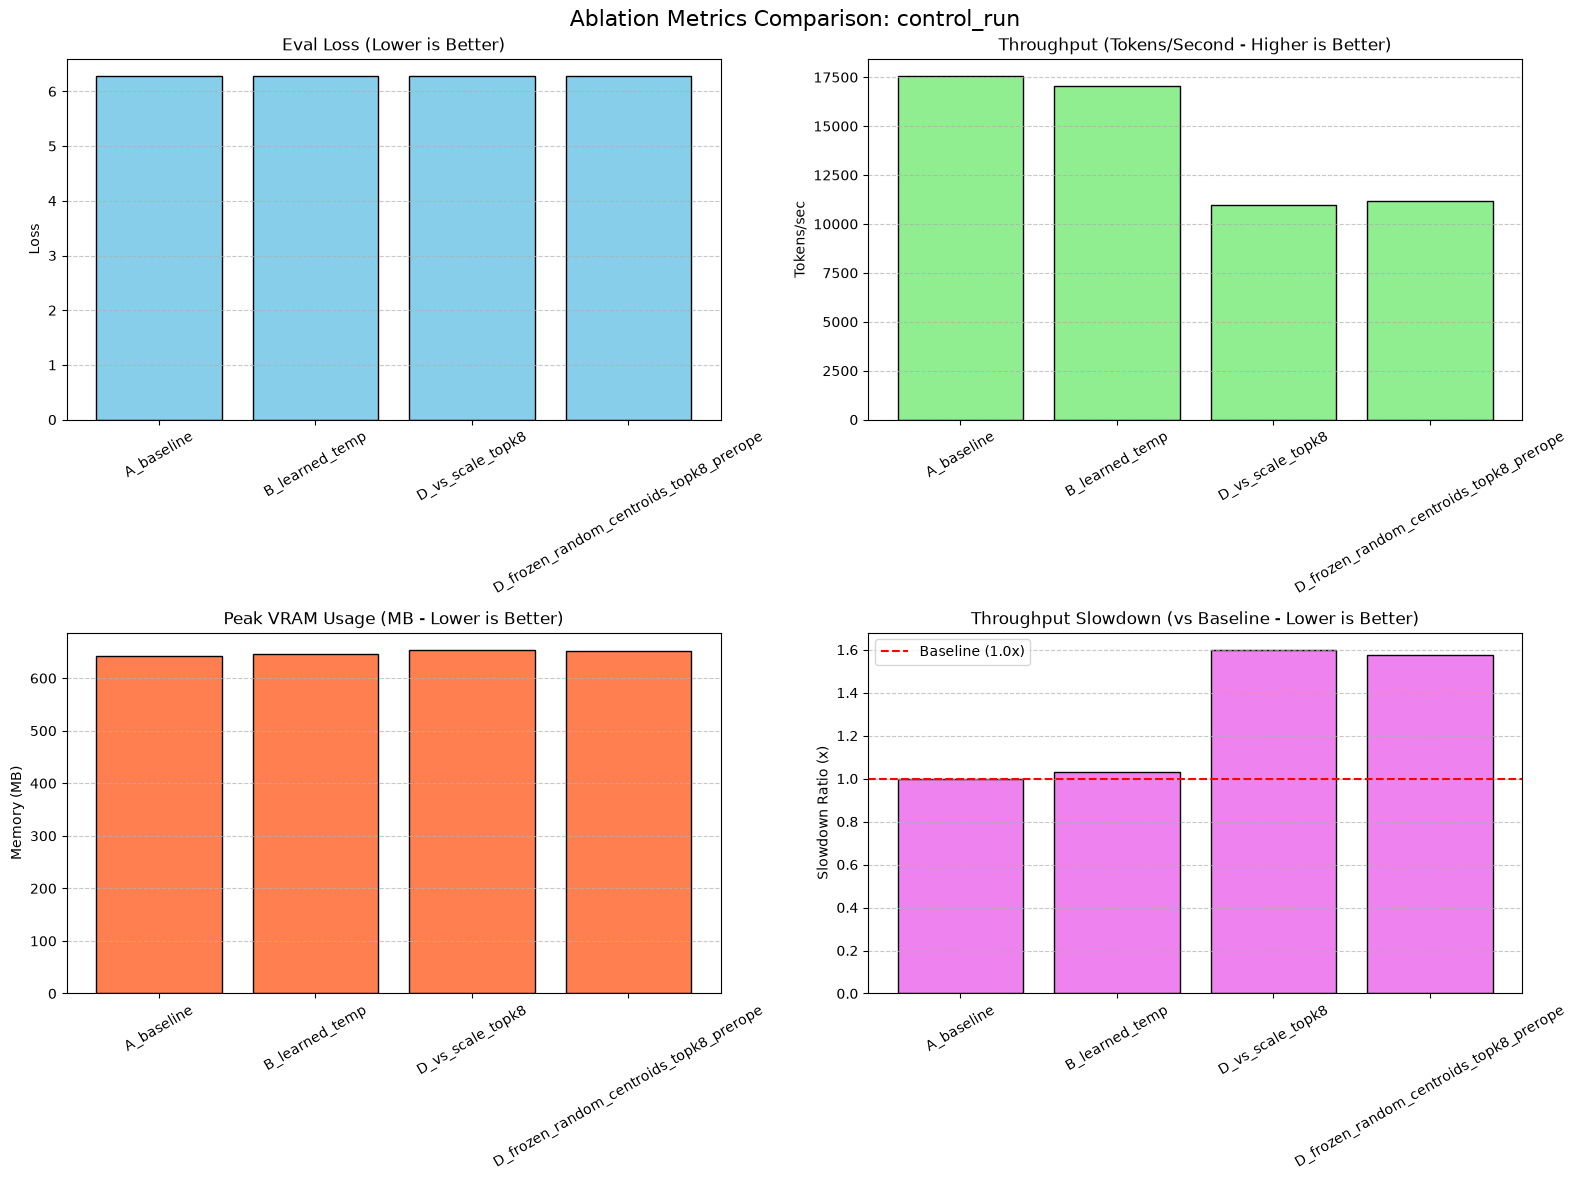

In [585]:
if run_to_analyze:
    # Look for ablation_results.csv first, fallback to reevaluation_results.csv if present
    summary_file = os.path.join(run_to_analyze, "ablation_results.csv")
    reeval_file = os.path.join(run_to_analyze, "reevaluation_results.csv")
    
    df_summary = None
    if os.path.exists(summary_file):
        df_summary = pd.read_csv(summary_file)
        
    df_reeval = None
    if os.path.exists(reeval_file):
        df_reeval = pd.read_csv(reeval_file)
        
    # We will plot using df_summary or df_reeval
    plot_df = df_summary if df_summary is not None else df_reeval
    
    if plot_df is not None and not plot_df.empty:
        # Determine if we should plot slowdown
        has_slowdown = 'slowdown_vs_baseline' in plot_df.columns
        
        # Handle multi-seed naming
        plot_df = plot_df.copy()
        if 'seed' in plot_df.columns:
            plot_df['plot_name'] = plot_df['name'] + " (" + plot_df['seed'].astype(str) + ")"
            x_col = 'plot_name'
        else:
            x_col = 'name'
            
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))
        
        # 1. Eval Loss comparison (using df_reeval if available since it is more accurate)
        loss_df = df_reeval if df_reeval is not None else plot_df
        loss_df = loss_df.copy()
        if 'seed' in loss_df.columns:
            loss_df['plot_name'] = loss_df['name'] + " (" + loss_df['seed'].astype(str) + ")"
            loss_x_col = 'plot_name'
        else:
            loss_x_col = 'name'
            
        axes[0, 0].bar(loss_df[loss_x_col], loss_df['loss'], color='skyblue', edgecolor='black')
        axes[0, 0].set_title("Eval Loss (Lower is Better)")
        axes[0, 0].set_ylabel("Loss")
        axes[0, 0].tick_params(axis='x', rotation=30)
        axes[0, 0].grid(True, axis='y', linestyle='--', alpha=0.7)
        
        # 2. Throughput comparison
        if 'tokens_per_sec' in plot_df.columns:
            axes[0, 1].bar(plot_df[x_col], plot_df['tokens_per_sec'], color='lightgreen', edgecolor='black')
            axes[0, 1].set_title("Throughput (Tokens/Second - Higher is Better)")
            axes[0, 1].set_ylabel("Tokens/sec")
            axes[0, 1].tick_params(axis='x', rotation=30)
            axes[0, 1].grid(True, axis='y', linestyle='--', alpha=0.7)
            
        # 3. Peak VRAM memory
        if 'peak_mem_mb' in plot_df.columns:
            axes[1, 0].bar(plot_df[x_col], plot_df['peak_mem_mb'], color='coral', edgecolor='black')
            axes[1, 0].set_title("Peak VRAM Usage (MB - Lower is Better)")
            axes[1, 0].set_ylabel("Memory (MB)")
            axes[1, 0].tick_params(axis='x', rotation=30)
            axes[1, 0].grid(True, axis='y', linestyle='--', alpha=0.7)
            
        # 4. Throughput Slowdown
        if has_slowdown:
            axes[1, 1].bar(plot_df[x_col], plot_df['slowdown_vs_baseline'], color='violet', edgecolor='black')
            axes[1, 1].set_title("Throughput Slowdown (vs Baseline - Lower is Better)")
            axes[1, 1].set_ylabel("Slowdown Ratio (x)")
            axes[1, 1].axhline(y=1.0, color='red', linestyle='--', label='Baseline (1.0x)')
            axes[1, 1].tick_params(axis='x', rotation=30)
            axes[1, 1].grid(True, axis='y', linestyle='--', alpha=0.7)
            axes[1, 1].legend()
            
        plt.suptitle(f"Ablation Metrics Comparison: {os.path.basename(run_to_analyze)}", fontsize=16, y=0.98)
        plt.tight_layout()
        plt.show()

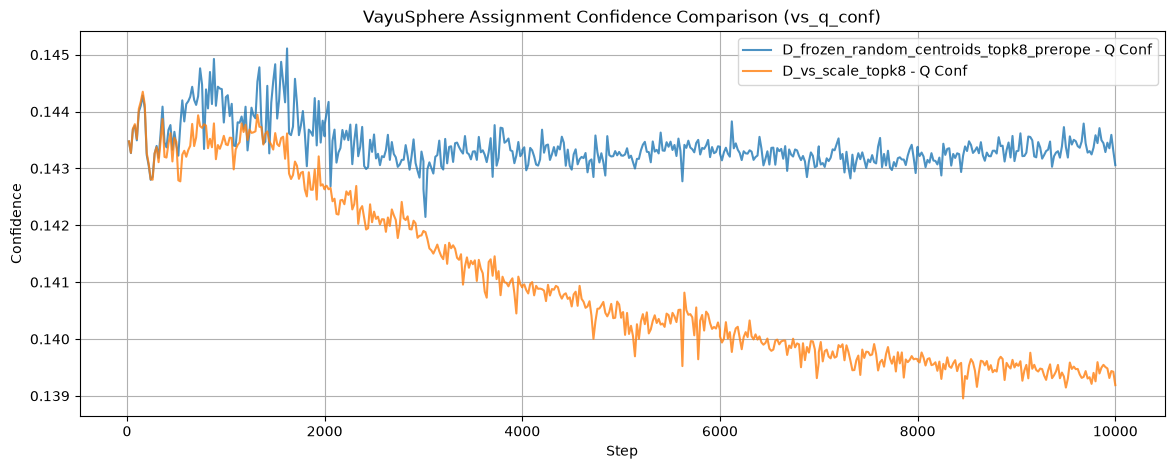

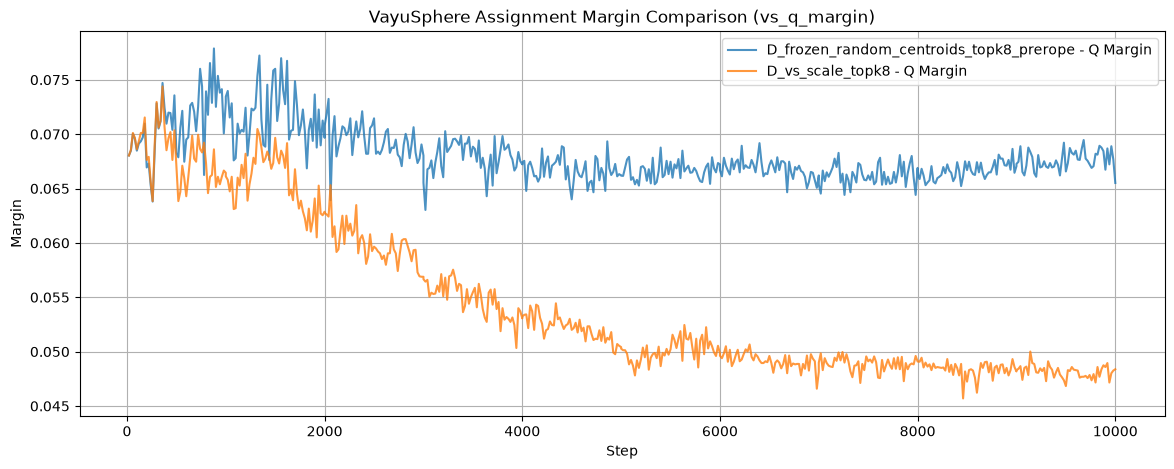

In [586]:
if run_to_analyze:
    subdirs = [d for d in os.listdir(run_to_analyze) if os.path.isdir(os.path.join(run_to_analyze, d))]
    all_metrics = []
    for sd in subdirs:
        if sd.startswith("seed"):
            seed_dir = os.path.join(run_to_analyze, sd)
            inner_dirs = [d for d in os.listdir(seed_dir) if os.path.isdir(os.path.join(seed_dir, d))]
            for idir in inner_dirs:
                all_metrics.append((f"{sd}/{idir}", os.path.join(seed_dir, idir, "metrics.csv")))
        else:
            all_metrics.append((sd, os.path.join(run_to_analyze, sd, "metrics.csv")))
            
    # We want to plot gate confidences side-by-side for all active variants
    plt.figure(figsize=(14, 5))
    has_plots = False
    
    for label, metrics_file in all_metrics:
        if os.path.exists(metrics_file):
            df = pd.read_csv(metrics_file)
            if 'vs_q_conf' in df and not df['vs_q_conf'].dropna().empty:
                plt.plot(df['step'], df['vs_q_conf'].interpolate(), label=f"{label} - Q Conf", alpha=0.8)
                has_plots = True
                
    if has_plots:
        plt.title("VayuSphere Assignment Confidence Comparison (vs_q_conf)")
        plt.xlabel("Step")
        plt.ylabel("Confidence")
        plt.legend()
        plt.grid(True)
        plt.show()
        
    # Same for routing margins
    plt.figure(figsize=(14, 5))
    has_plots = False
    for label, metrics_file in all_metrics:
        if os.path.exists(metrics_file):
            df = pd.read_csv(metrics_file)
            if 'vs_q_margin' in df and not df['vs_q_margin'].dropna().empty:
                plt.plot(df['step'], df['vs_q_margin'].interpolate(), label=f"{label} - Q Margin", alpha=0.8)
                has_plots = True
                
    if has_plots:
        plt.title("VayuSphere Assignment Margin Comparison (vs_q_margin)")
        plt.xlabel("Step")
        plt.ylabel("Margin")
        plt.legend()
        plt.grid(True)
        plt.show()

In [587]:
if run_to_analyze:
    agg_file = os.path.join(run_to_analyze, "aggregate_mean_std.csv")
    if os.path.exists(agg_file):
        df_agg = pd.read_csv(agg_file)
        
        # Plot multi-seed aggregated metrics
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        
        # 1. Mean Loss with Std Dev error bars
        axes[0].errorbar(df_agg['name'], df_agg['mean_loss'], yerr=df_agg['std_loss'], fmt='o', color='darkblue', ecolor='red', capsize=5, elinewidth=2, markeredgecolor='black', markersize=8)
        axes[0].set_title("Aggregated Loss (Mean ± Std Dev)")
        axes[0].set_ylabel("Eval Loss")
        axes[0].tick_params(axis='x', rotation=30)
        axes[0].grid(True, linestyle='--', alpha=0.7)
        
        # 2. Mean Slowdown vs Baseline
        axes[1].bar(df_agg['name'], df_agg['mean_slowdown_vs_baseline'], color='purple', edgecolor='black', alpha=0.7)
        axes[1].axhline(y=1.0, color='red', linestyle='--', label='Baseline (1.0x)')
        axes[1].set_title("Mean Throughput Slowdown (vs Baseline)")
        axes[1].set_ylabel("Slowdown Ratio (x)")
        axes[1].tick_params(axis='x', rotation=30)
        axes[1].grid(True, axis='y', linestyle='--', alpha=0.7)
        axes[1].legend()
        
        # 3. Win Count
        axes[2].bar(df_agg['name'], df_agg['win_count'], color='orange', edgecolor='black', alpha=0.7)
        axes[2].set_title("Win Count (Lower Loss than Baseline)")
        axes[2].set_ylabel("Seeds Won (out of 3)")
        axes[2].set_ylim(0, 3.5)
        axes[2].tick_params(axis='x', rotation=30)
        axes[2].grid(True, axis='y', linestyle='--', alpha=0.7)
        
        plt.suptitle(f"Aggregated Multi-Seed Analysis: {os.path.basename(run_to_analyze)}", fontsize=15, y=1.02)
        plt.tight_layout()
        plt.show()